# Credit Risk Prediction – Model Development

## Objective

The objective of this project is to develop a machine learning model
to predict loan default using the Home Credit dataset.

Two approaches are compared:

- Logistic Regression as a baseline model.
- XGBoost as a non-linear tree-based model.

Because the target variable is highly imbalanced, model performance
is evaluated using ROC-AUC, PR-AUC, Precision, Recall, and F1-score
rather than accuracy alone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier

import joblib

In [6]:
#Charge the data
df = pd.read_csv("application_train.csv")

print(f"Dataset shape: {df.shape}")

Dataset shape: (307511, 122)


In [7]:
#Little confirmation

df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

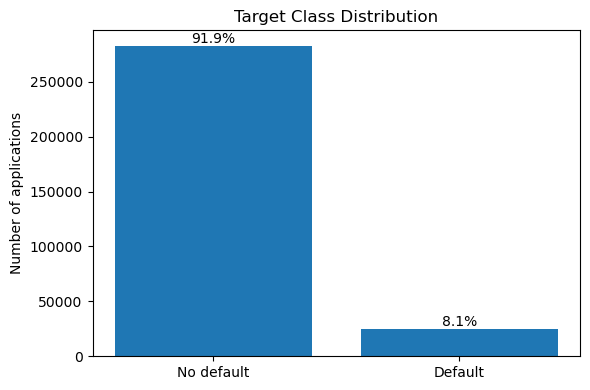

In [11]:
#Let's visualize the target
target_counts = df["TARGET"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ["No default", "Default"],
    target_counts.values
)

plt.title("Target Class Distribution")
plt.ylabel("Number of applications")

plt.tight_layout()

total = target_counts.sum()

for i, value in enumerate(target_counts.values):
    percentage = value / total * 100

    plt.text(
        i,
        value,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Train/Validation split

In [12]:
X = df.drop(columns="TARGET")
y = df["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (246008, 121)
Validation set: (61503, 121)


In [13]:
#Reprocesing
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 105
Categorical features: 16


In [14]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Here I need the BASELINE

In [15]:
#Now the BASELINE
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

In [16]:
#And start the TRAIN
baseline.fit(X_train, y_train)
#PREDICTIONS
y_prob_baseline = baseline.predict_proba(X_valid)[:, 1]
y_pred_baseline = baseline.predict(X_valid)

In [17]:
#Create a function for metrics
def evaluate_model(y_true, y_pred, y_prob):
    
    return {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

In [18]:
baseline_metrics = evaluate_model(
    y_valid,
    y_pred_baseline,
    y_prob_baseline
)

baseline_metrics

{'ROC-AUC': 0.7486851449480973,
 'PR-AUC': 0.22795259749883817,
 'Precision': 0.161818356374808,
 'Recall': 0.6789526686807653,
 'F1': 0.26134821878513004}

### XGBoost! (Extreme Gradient Boosting)

In [19]:
# For XGBoost I use the transformed representation for the
# same preprocessor.
# This allows us to know how much our dataset grew after One-Hot Encoding.
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print(X_train_processed.shape)

(246008, 245)


In [20]:
#XGBoost

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

### Training starts and prediction is coming

In [21]:
#Training
xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[
        (X_valid_processed, y_valid)
    ],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [23]:
#Predictions

y_prob_xgb = xgb_model.predict_proba(
    X_valid_processed
)[:, 1]

y_pred_xgb = (
    y_prob_xgb >= 0.5
).astype(int)

xgb_metrics = evaluate_model(
    y_valid,
    y_pred_xgb,
    y_prob_xgb
)

xgb_metrics

{'ROC-AUC': 0.761333111539523,
 'PR-AUC': 0.2515058415157893,
 'Precision': 0.5800865800865801,
 'Recall': 0.026988922457200405,
 'F1': 0.05157813702848345}

### Let's compare with an important table

In [24]:
results = pd.DataFrame(
    [baseline_metrics, xgb_metrics],
    index=["Logistic Regression", "XGBoost"]
)

results.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression,0.7487,0.2280,0.1618,0.679,0.2613
XGBoost,0.7613,0.2515,0.5801,0.027,0.0516


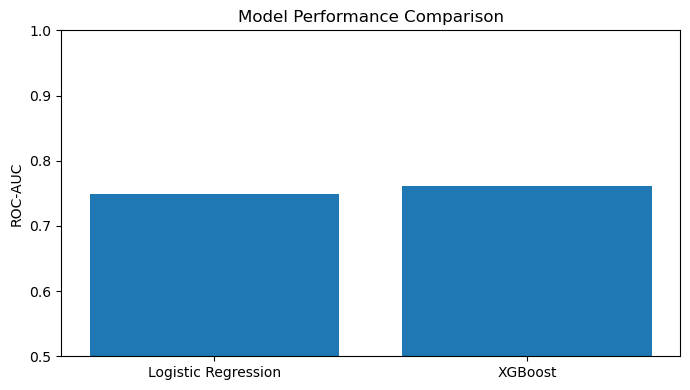

In [28]:
# I prefer to viualize it

plt.figure(figsize=(7, 4))

plt.bar(
    results.index,
    results["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title("Model Performance Comparison")

plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

### ROC Curve (ROC= Receiver Operating Characteristic)

<Figure size 700x500 with 0 Axes>

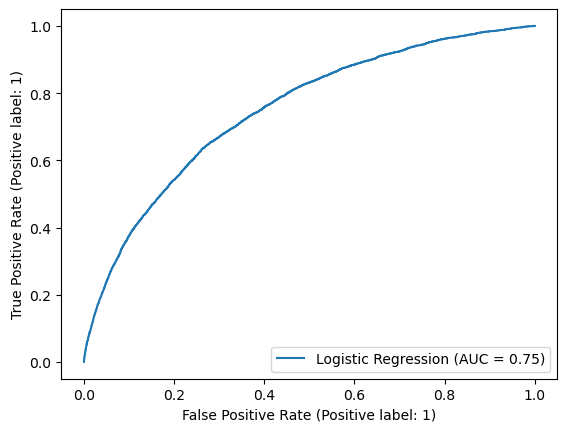

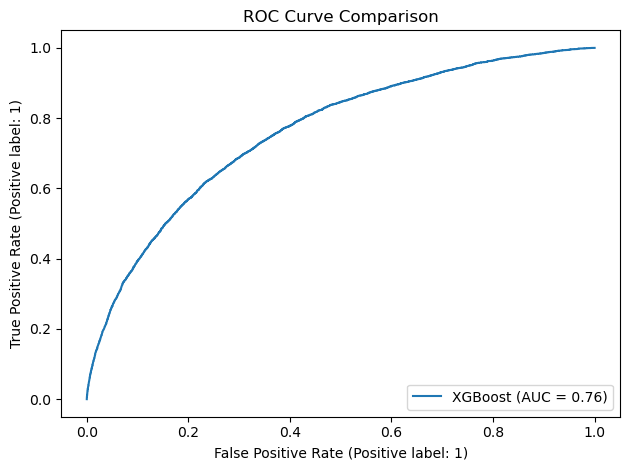

In [29]:
#ROC Curve
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_valid,
    y_prob_baseline,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_valid,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

### Precision - Recall Curve

<Figure size 700x500 with 0 Axes>

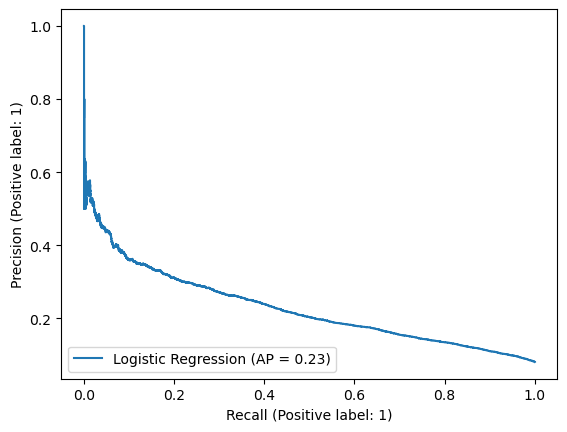

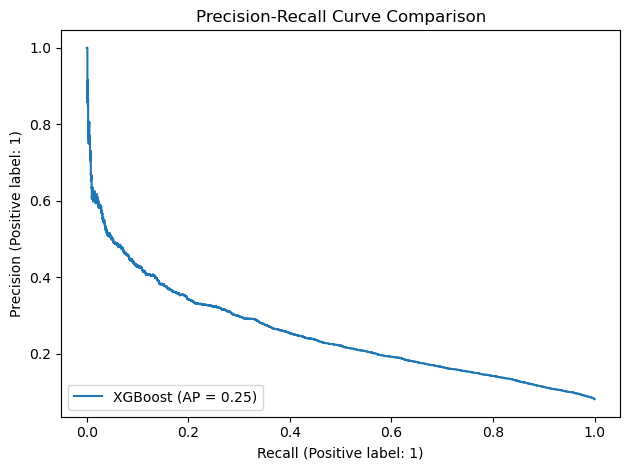

In [30]:
#Due to the significant imbalance at Home Credit, this visualization is also important:

plt.figure(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_prob_baseline,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()

### XGBoost Confusion Matrix

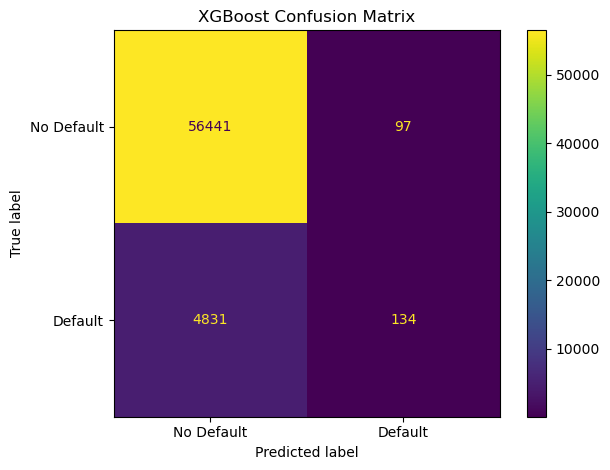

In [31]:
# This is for XGBoost
cm = confusion_matrix(
    y_valid,
    y_pred_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [34]:
# I save the model, so I won't need to train it again
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

import joblib

joblib.dump(
    xgb_model,
    models_dir / "xgboost_model.joblib"
)

joblib.dump(
    preprocessor,
    models_dir / "preprocessor.joblib"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.
